# Emotional Food AI 🍜
**Project Overview**

This project aims to recommend food based on a person's **emotion** and the current **weather condition**. The dataset contains 1,000+ samples combining emotions, weather types, and suitable food items.

**Problem Statement:**
- People often choose food based on mood and weather.
- Choosing the right food for comfort or satisfaction can be difficult.

**Solution:**
- Use a **Machine Learning model** (Decision Tree) to predict suitable food based on:
    - Input features: `emotion` and `weather`
    - Output: `food recommendation`

## Dataset

In this step, i will load our dataset containing 1,000+ samples.  
The dataset includes three columns:

- `emotion` → the user's emotion (happy, sad, stressed, etc.)
- `weather` → current weather condition (hot, cold, rainy, etc.)
- `food` → recommended food for that emotion and weather

I will use **pandas** to read the CSV file into a DataFrame and display the first few rows.

In [99]:
import pandas as pd

df = pd.read_csv("../data/emotional_food_1000.csv")

df.head()

,emotion,weather,food
0,tired,rainy,Porridge
1,sad,cold,Soup
2,sad,rainy,Tom Yum Soup
3,excited,rainy,Pizza
4,sad,rainy,Tom Yum Soup


## Explore Dataset

After loading the dataset, we need to explore it to understand its structure and distribution.  
I will use the following commands:

1. `df.info()` → To check the data types, number of non-null entries, and column names.  
2. `df.describe(include='all')` → To see summary statistics for all columns.  
3. `df['emotion'].value_counts()` → To count how many times each emotion appears in the dataset.

This helps us detect missing data and understand the distribution of our features.

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  999 non-null    object
 1   weather  999 non-null    object
 2   food     999 non-null    object
dtypes: object(3)
memory usage: 23.5+ KB


In [101]:
df.describe(include='all')

,emotion,weather,food
count,999,999,999
unique,8,5,16
top,sad,rainy,Fried Chicken
freq,135,217,184


In [102]:
df['emotion'].value_counts()

emotion
sad         135
stressed    133
relaxed     130
angry       128
happy       128
tired       118
bored       118
excited     109
Name: count, dtype: int64

## Visualize Dataset

Visualization helps us understand the distribution of our features more clearly.

1. Bar plot for `weather` → Shows how many samples are present for each weather type.  
2. Pie chart for `emotion` → Shows the percentage of each emotion in the dataset.

We use **matplotlib** to create these plots.

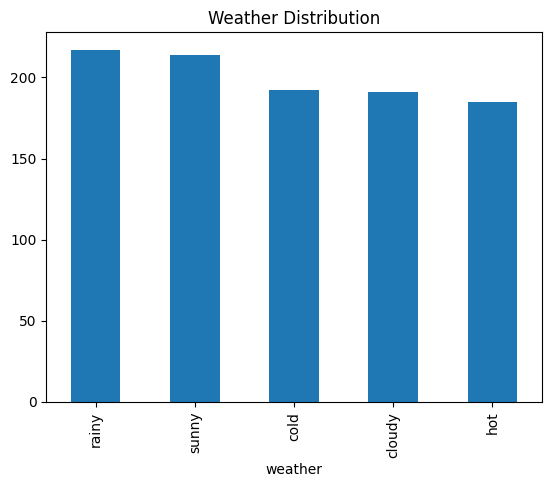

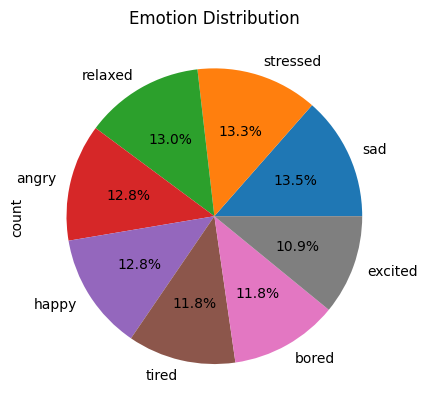

In [103]:
import matplotlib.pyplot as plt

df['weather'].value_counts().plot(kind='bar')
plt.title("Weather Distribution")
plt.show()

df['emotion'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Emotion Distribution")
plt.show()

## Data Preprocessing & Train/Test Split

Before training our Machine Learning model, we need to:

1. Convert categorical text data into numeric labels using `LabelEncoder`.  
   - `emotion`, `weather`, and `food` are all categorical columns.  
2. Split the dataset into **features (X)** and **target (y)**.  
3. Divide data into **training set** and **testing set** using `train_test_split` (80% train, 20% test).  
4. Display `X` to verify preprocessing.

In [104]:
from sklearn.preprocessing import LabelEncoder

le_emotion = LabelEncoder()
le_weather = LabelEncoder()
le_food = LabelEncoder()

df['emotion'] = le_emotion.fit_transform(df['emotion'])
df['weather'] = le_weather.fit_transform(df['weather'])

# Separate features and target
X = df[['emotion', 'weather']]
y = le_food.fit_transform(df['food'])

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display features to verify
display(X.head())

,emotion,weather
0,7,3
1,5,1
2,5,3
3,2,3
4,5,3


## Train Machine Learning Model

In this step, we will train a **Decision Tree Classifier** to predict the recommended food based on emotion and weather.

Steps included:

1. Encode categorical variables (`emotion`, `weather`, `food`) into numeric values using `LabelEncoder`.  
2. Split the dataset into **features (X)** and **target (y)**, then divide into **training** and **testing** sets (80% train, 20% test).  
3. Train a **Decision Tree Classifier** on the training data.

In [105]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

RandomForestClassifier()

## Prediction with User Input

In this step, we allow the user to input their **emotion** and **current weather**, then use the trained model to recommend a food.  

Steps:

1. Display a menu for `emotion` and `weather` with numeric codes.  
2. Get user input for `emotion` and `weather`.  
3. Convert input into a format suitable for the model.  
4. Use the trained `Decision Tree` model to predict the recommended food.  
5. Convert the numeric prediction back to the original food name using the `LabelEncoder`.  
6. Print the recommended food.

In [117]:
print("=== Emotion Menu ===")
print("0 = happy, 1 = sad, 2 = stressed, 3 = bored, 4 = angry, 5 = relaxed")

print("\n=== Weather Menu ===")
print("0 = hot, 1 = rainy, 2 = cold, 3 = cloudy, 4 = windy")

# รับ input
emotion_num = int(input("\nEnter emotion number: "))
weather_num = int(input("Enter weather number: "))

# สร้าง DataFrame ให้เหมือนตอน train
input_data = pd.DataFrame([[emotion_num, weather_num]], columns=['emotion','weather'])

# ทำนาย
pred = model.predict(input_data)

# แปลงกลับเป็นชื่ออาหาร
result = le_food.inverse_transform(pred)

print("\nRecommended Food:", result[0])

=== Emotion Menu ===
0 = happy, 1 = sad, 2 = stressed, 3 = bored, 4 = angry, 5 = relaxed

=== Weather Menu ===
0 = hot, 1 = rainy, 2 = cold, 3 = cloudy, 4 = windy

Recommended Food: Noodles
